# Biohub – Cell Tracking During Development

## Chapter 25: Build and Evaluate Ranking Ensembles

**Objective:** Combine the Chapter 24 binary classifier and distance regressor rankings, then test whether rank fusion improves held-out top-k candidate recovery.

This notebook compares five approaches:

1. **Binary classifier only** — baseline
2. **Distance regressor only** — baseline
3. **Average normalized rank**
4. **Reciprocal Rank Fusion (RRF)** ⭐
5. **Weighted normalized rank fusion** — optional

This notebook remains self-contained and includes `!pip install -q zarr`, explicit data loading, candidate generation, model training, ensemble construction, top-k evaluation, oracle-good retention, compression analysis, and overlays.


# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- explain why ranks are safer to combine than incompatible raw model scores
- train the binary classifier and distance regressor on the same candidate pool
- convert both model outputs into comparable rankings
- build average normalized rank fusion
- build Reciprocal Rank Fusion (RRF)
- build a weighted rank-fusion baseline
- compare all methods at top-25, top-50, top-100, and top-200
- measure GT recall, precision-like score, oracle-good retention, and compression
- select the best ranking approach for the next detector pipeline


# 🧠 Lesson Notes

Chapter 24 showed that the binary classifier and distance regressor make different useful mistakes. Their Spearman rank correlation was only about 0.49, and each model uniquely recovered some oracle-good candidates.

That is evidence of **complementarity**.

However, their raw outputs cannot be averaged directly:

- classifier output: `P(oracle_good)` — larger is better
- regressor output: predicted distance — smaller is better

This chapter therefore combines the models using **ranks**.

## Ensemble methods

### Average normalized rank
Converts both ranks to the range 0–1 and averages them. Smaller is better.

### Reciprocal Rank Fusion
Uses:

```text
RRF = 1 / (k + binary_rank) + 1 / (k + distance_rank)
```

Larger is better. RRF rewards candidates that either model ranks highly while remaining robust to scale differences.

### Weighted rank fusion
Allows one model to receive more influence than the other. The default gives 40% weight to the classifier and 60% to the distance regressor.


# 🗺️ Chapter Roadmap

1. Install and import packages  
2. Load competition data  
3. Rebuild the shared candidate pool  
4. Train the binary classifier and distance regressor  
5. Recreate the Chapter 24 baseline rankings  
6. Build average normalized rank fusion  
7. Build Reciprocal Rank Fusion  
8. Build weighted rank fusion  
9. Evaluate every method at multiple top-k cutoffs  
10. Compare recall, precision-like score, oracle-good retention, and compression  
11. Visualize the best ensemble predictions  
12. Select the ranking method for the next detector pipeline


In [1]:

!pip install -q zarr

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from IPython.display import display

print("Imports successful.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.8 MB/s eta 0:00:00
Imports successful.


# Step 1 — Load the Attached Competition Data

Attaching data does not automatically create Python variables. This cell explicitly creates `image` and `nodes_df`.


In [2]:

base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"
train_path = base / "train"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

print("Competition path exists:", base.exists())
print("Image path exists:", zarr_path.exists())
print("GEFF path exists:", geff_path.exists())

if not base.exists():
    raise FileNotFoundError("Attach the competition data in Kaggle, then rerun this cell.")

image_root = zarr.open(zarr_path, mode="r")
image = image_root["0"]
geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Competition path exists: True
Image path exists: True
GEFF path exists: True
Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Shared Detection, Evaluation, and Feature Helpers


In [3]:

def pairwise_distances_3d(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)
    return cdist(a, b)


def evaluate_predictions(gt_points, pred_points, match_radius=6):
    num_gt, num_pred = len(gt_points), len(pred_points)
    if num_gt == 0 or num_pred == 0:
        return {
            "num_gt": num_gt, "num_pred": num_pred,
            "gt_detected": 0, "gt_missed": num_gt,
            "pred_matched": 0, "pred_unmatched": num_pred,
            "gt_recall": 0.0 if num_gt else np.nan,
            "pred_precision_like": 0.0 if num_pred else np.nan,
        }
    dist = pairwise_distances_3d(gt_points, pred_points)
    gt_detected = int((dist.min(axis=1) <= match_radius).sum())
    pred_matched = int((dist.min(axis=0) <= match_radius).sum())
    return {
        "num_gt": num_gt, "num_pred": num_pred,
        "gt_detected": gt_detected, "gt_missed": num_gt-gt_detected,
        "pred_matched": pred_matched, "pred_unmatched": num_pred-pred_matched,
        "gt_recall": gt_detected/num_gt,
        "pred_precision_like": pred_matched/num_pred,
    }


def extract_patch_3d(volume, z, y, x, rz=2, ryx=4):
    z0=max(0,z-rz); z1=min(volume.shape[0],z+rz+1)
    y0=max(0,y-ryx); y1=min(volume.shape[1],y+ryx+1)
    x0=max(0,x-ryx); x1=min(volume.shape[2],x+ryx+1)
    return volume[z0:z1,y0:y1,x0:x1], (z0,z1,y0,y1,x0,x1)


In [4]:

def compute_candidate_features(frame_3d, candidate_df, patch_radius=4, rz=2, ryx=4):
    rows=[]
    for _,r in candidate_df.iterrows():
        z,y,x=int(r.z),int(r.y),int(r.x)
        sigma=float(r.sigma)
        y0=max(0,y-patch_radius); y1=min(frame_3d.shape[1],y+patch_radius+1)
        x0=max(0,x-patch_radius); x1=min(frame_3d.shape[2],x+patch_radius+1)
        patch2=frame_3d[z,y0:y1,x0:x1]
        patch3,b=extract_patch_3d(frame_3d,z,y,x,rz=rz,ryx=ryx)
        z0,z1,yy0,yy1,xx0,xx1=b
        lz,ly,lx=z-z0,y-yy0,x-xx0
        center=float(frame_3d[z,y,x])
        pmean=float(patch2.mean()); pmax=float(patch2.max()); pstd=float(patch2.std())
        py,px=np.unravel_index(np.argmax(patch2),patch2.shape)
        cy=(patch2.shape[0]-1)/2; cx=(patch2.shape[1]-1)/2
        maxdist=float(np.sqrt((py-cy)**2+(px-cx)**2))
        yy,xx=np.indices(patch2.shape); mass2=patch2.astype(float)
        if mass2.sum()>0:
            comy=(yy*mass2).sum()/mass2.sum(); comx=(xx*mass2).sum()/mass2.sum()
            comoff=float(np.sqrt((comy-cy)**2+(comx-cx)**2))
        else: comoff=0.0
        vol_mean=float(patch3.mean()); vol_std=float(patch3.std()); vol_max=float(patch3.max())
        zline=patch3[:,ly,lx]
        neighbors=[]
        if lz>0: neighbors.append(patch3[lz-1])
        if lz+1<patch3.shape[0]: neighbors.append(patch3[lz+1])
        neighbor_mean=float(np.mean([s.mean() for s in neighbors])) if neighbors else vol_mean
        peakz,peaky,peakx=np.unravel_index(np.argmax(patch3),patch3.shape)
        zz,yyy,xxx=np.indices(patch3.shape); mass3=patch3.astype(float)
        if mass3.sum()>0:
            comz=(zz*mass3).sum()/mass3.sum(); comy3=(yyy*mass3).sum()/mass3.sum(); comx3=(xxx*mass3).sum()/mass3.sum()
            comoff3=float(np.sqrt((comz-lz)**2+(comy3-ly)**2+(comx3-lx)**2))
        else: comoff3=0.0
        rows.append({
            "z":z,"y":y,"x":x,"sigma":sigma,
            "center_intensity":center,"patch_mean":pmean,"patch_max":pmax,"patch_std":pstd,
            "local_contrast":pmax-pmean,"center_to_patch_max_dist":maxdist,
            "patch_com_offset":comoff,
            "is_near_border":int(y<=patch_radius or y>=frame_3d.shape[1]-patch_radius-1 or x<=patch_radius or x>=frame_3d.shape[2]-patch_radius-1),
            "center_voxel":float(patch3[lz,ly,lx]),"vol_mean":vol_mean,"vol_std":vol_std,"vol_max":vol_max,
            "z_line_mean":float(zline.mean()),"z_line_std":float(zline.std()),"z_line_max":float(zline.max()),
            "center_over_vol_mean":center/(vol_mean+1e-6),"center_minus_vol_mean":center-vol_mean,
            "center_slice_minus_neighbor_mean":float(patch3[lz].mean()-neighbor_mean),
            "slice_mean_std":float(np.std([s.mean() for s in patch3])),
            "z_peak_offset":int(abs(peakz-lz)),"mass_center_offset_3d":comoff3,
            "peak_to_mean_ratio":vol_max/(vol_mean+1e-6),"bright_fraction":float((patch3>vol_mean).mean()),
        })
    return pd.DataFrame(rows)


In [5]:

def build_candidate_table(image,nodes_df,t,log_kwargs,oracle_radius=6,nms_radius=3.0):
    frame=np.asarray(image[t]); gt=nodes_df[nodes_df.t==t].copy().reset_index(drop=True)
    rows=[]
    for z in range(frame.shape[0]):
        sl=frame[z].astype(np.float32); mn,mx=float(sl.min()),float(sl.max())
        if mx<=mn: continue
        sl=(sl-mn)/(mx-mn)
        blobs=blob_log(sl,**log_kwargs)
        for y,x,sigma in blobs:
            y=int(np.clip(round(y),0,frame.shape[1]-1)); x=int(np.clip(round(x),0,frame.shape[2]-1))
            rows.append({"z":z,"y":y,"x":x,"sigma":float(sigma),"nms_score":float(frame[z,y,x])})
    blob=pd.DataFrame(rows)
    if len(blob)==0: return pd.DataFrame(),gt,frame
    blob=blob.drop_duplicates(["z","y","x"]).sort_values("nms_score",ascending=False).reset_index(drop=True)
    kept=[]; work=blob.copy()
    while len(work)>0:
        r=work.iloc[0].copy(); kept.append(r)
        p=np.array([r.z,r.y,r.x],float); pts=work[["z","y","x"]].to_numpy(float)
        d=np.sqrt(((pts-p)**2).sum(axis=1)); work=work[d>nms_radius].reset_index(drop=True)
    base=pd.DataFrame(kept).reset_index(drop=True)
    gtpts=gt[["z","y","x"]].to_numpy(float); candpts=base[["z","y","x"]].to_numpy(float)
    base["nearest_gt_dist"]=pairwise_distances_3d(gtpts,candpts).min(axis=0) if len(gtpts) else np.inf
    base["oracle_good"]=base.nearest_gt_dist<=oracle_radius
    feats=compute_candidate_features(frame,base[["z","y","x","sigma"]])
    out=base.merge(feats,on=["z","y","x"],how="left",suffixes=("","_feat")).drop(columns=["nms_score"],errors="ignore")
    return out,gt,frame


# Step 3 — Shared Experiment Configuration


In [6]:

train_timesteps=[0,8,20,40]
heldout_timesteps=[60,80]
oracle_radius=6
nms_radius=3.0
distance_clip=20.0
log_kwargs={"min_sigma":2.5,"max_sigma":3.5,"num_sigma":3,"threshold":0.15}


# Step 4 — Build Shared Training and Held-Out Candidate Tables


In [7]:

train_parts=[]
for t in train_timesteps:
    df,gt,frame=build_candidate_table(image,nodes_df,t,log_kwargs,oracle_radius,nms_radius)
    if len(df)==0:
        print(f"WARNING: no candidates at t={t}"); continue
    df["t"]=t; train_parts.append(df)
    print(f"train t={t}: candidates={len(df)}, oracle_good={int(df.oracle_good.sum())}")
if not train_parts: raise RuntimeError("No training candidate tables were created.")
train_df=pd.concat(train_parts,ignore_index=True)

heldout_parts=[]; heldout_gt={}; heldout_frames={}
for t in heldout_timesteps:
    df,gt,frame=build_candidate_table(image,nodes_df,t,log_kwargs,oracle_radius,nms_radius)
    if len(df)==0:
        print(f"WARNING: no candidates at t={t}"); continue
    df["t"]=t; heldout_parts.append(df); heldout_gt[t]=gt; heldout_frames[t]=frame
    print(f"heldout t={t}: candidates={len(df)}, oracle_good={int(df.oracle_good.sum())}")
if not heldout_parts: raise RuntimeError("No held-out candidate tables were created.")
heldout_df=pd.concat(heldout_parts,ignore_index=True)
print("Training rows:",len(train_df),"Held-out rows:",len(heldout_df))


train t=0: candidates=670, oracle_good=12
train t=8: candidates=661, oracle_good=12
train t=20: candidates=695, oracle_good=14
train t=40: candidates=688, oracle_good=11
heldout t=60: candidates=807, oracle_good=13
heldout t=80: candidates=884, oracle_good=6
Training rows: 2714 Held-out rows: 1691


# Step 5 — Define Shared Features and Train Both Models


In [8]:

feature_cols=[
"sigma","center_intensity","patch_mean","patch_max","patch_std","local_contrast",
"center_to_patch_max_dist","patch_com_offset","is_near_border","center_voxel","vol_mean","vol_std","vol_max",
"z_line_mean","z_line_std","z_line_max","center_over_vol_mean","center_minus_vol_mean",
"center_slice_minus_neighbor_mean","slice_mean_std","z_peak_offset","mass_center_offset_3d",
"peak_to_mean_ratio","bright_fraction"]
missing=[c for c in feature_cols if c not in train_df.columns or c not in heldout_df.columns]
if missing: raise KeyError(f"Missing features: {missing}")
X=train_df[feature_cols].fillna(0.0)

binary_model=RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=3,class_weight="balanced_subsample",random_state=42,n_jobs=-1)
binary_model.fit(X,train_df.oracle_good.astype(int))

train_df["target_dist"]=train_df.nearest_gt_dist.clip(0,distance_clip)
distance_model=RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_leaf=5,random_state=42,n_jobs=-1)
distance_model.fit(X,train_df.target_dist)
print("Both models trained.")


Both models trained.


# Step 6 — Score and Rank the Same Held-Out Candidates


In [9]:

parts=[]
for t in heldout_timesteps:
    d=heldout_df[heldout_df.t==t].copy(); Xt=d[feature_cols].fillna(0.0)
    d["binary_prob_good"]=binary_model.predict_proba(Xt)[:,1]
    d["pred_dist"]=distance_model.predict(Xt)
    d["binary_rank"]=d.binary_prob_good.rank(method="first",ascending=False).astype(int)
    d["distance_rank"]=d.pred_dist.rank(method="first",ascending=True).astype(int)
    d["rank_difference"]=d.binary_rank-d.distance_rank
    parts.append(d)
comparison_df=pd.concat(parts,ignore_index=True)
display(comparison_df[["t","z","y","x","oracle_good","binary_prob_good","pred_dist","binary_rank","distance_rank","rank_difference"]].head())


,t,z,y,x,oracle_good,binary_prob_good,pred_dist,binary_rank,distance_rank,rank_difference
0,60,62.0,92.0,224.0,False,0.033068,18.716653,571,105,466
1,60,63.0,132.0,245.0,False,0.002925,19.537263,775,537,238
2,60,62.0,59.0,235.0,False,0.020856,19.269043,631,339,292
3,60,37.0,223.0,15.0,False,0.003268,19.619399,759,604,155
4,60,45.0,0.0,64.0,False,0.000000,19.824586,785,749,36


# Step 7 — Oracle-Good Rank Comparison


In [10]:

oracle_good_rank_comparison=(comparison_df[comparison_df.oracle_good][["t","z","y","x","nearest_gt_dist","binary_prob_good","pred_dist","binary_rank","distance_rank","rank_difference"]].sort_values(["t","distance_rank"]).reset_index(drop=True))
oracle_good_rank_comparison


,t,z,y,x,nearest_gt_dist,binary_prob_good,pred_dist,binary_rank,distance_rank,rank_difference
0,60,33.0,145.0,145.0,5.656854,0.074649,18.441782,412,58,354
1,60,24.0,204.0,71.0,5.099020,0.323078,18.577214,55,76,-21
2,60,14.0,6.0,151.0,3.741657,0.058146,18.736410,472,113,359
3,60,27.0,219.0,112.0,2.449490,0.171324,19.237185,215,316,-101
4,60,34.0,47.0,222.0,5.830952,0.076869,19.268803,405,338,67
5,60,25.0,215.0,110.0,4.242641,0.298209,19.305225,64,364,-300
6,60,16.0,195.0,63.0,4.898979,0.335182,19.397680,48,438,-390
7,60,41.0,156.0,64.0,4.358899,0.010814,19.582560,698,578,120
8,60,39.0,158.0,62.0,5.916080,0.113090,19.672009,323,644,-321
9,60,42.0,157.0,67.0,2.000000,0.018366,19.758094,642,706,-64


# Step 8 — Rank Summary by Model and Timepoint


In [11]:

rows=[]
for t in heldout_timesteps:
    d=comparison_df[comparison_df.t==t]; g=d[d.oracle_good]
    for name,col in [("binary_classifier","binary_rank"),("distance_regressor","distance_rank")]:
        rows.append({"t":t,"model":name,"num_candidates":len(d),"num_oracle_good":len(g),
        "best_good_rank":g[col].min(),"median_good_rank":g[col].median(),"worst_good_rank":g[col].max(),
        "good_in_top_25":int((g[col]<=25).sum()),"good_in_top_50":int((g[col]<=50).sum()),
        "good_in_top_100":int((g[col]<=100).sum()),"good_in_top_200":int((g[col]<=200).sum())})
rank_summary_df=pd.DataFrame(rows)
rank_summary_df


,t,model,num_candidates,num_oracle_good,best_good_rank,median_good_rank,worst_good_rank,good_in_top_25,good_in_top_50,good_in_top_100,good_in_top_200
0,60,binary_classifier,807,13,48,412.0,761,0,1,3,3
1,60,distance_regressor,807,13,58,438.0,754,0,0,2,3
2,80,binary_classifier,884,6,118,157.0,474,0,0,0,4
3,80,distance_regressor,884,6,28,67.0,176,0,3,4,6


# Step 9 — Rank Scatter Plot and Correlation


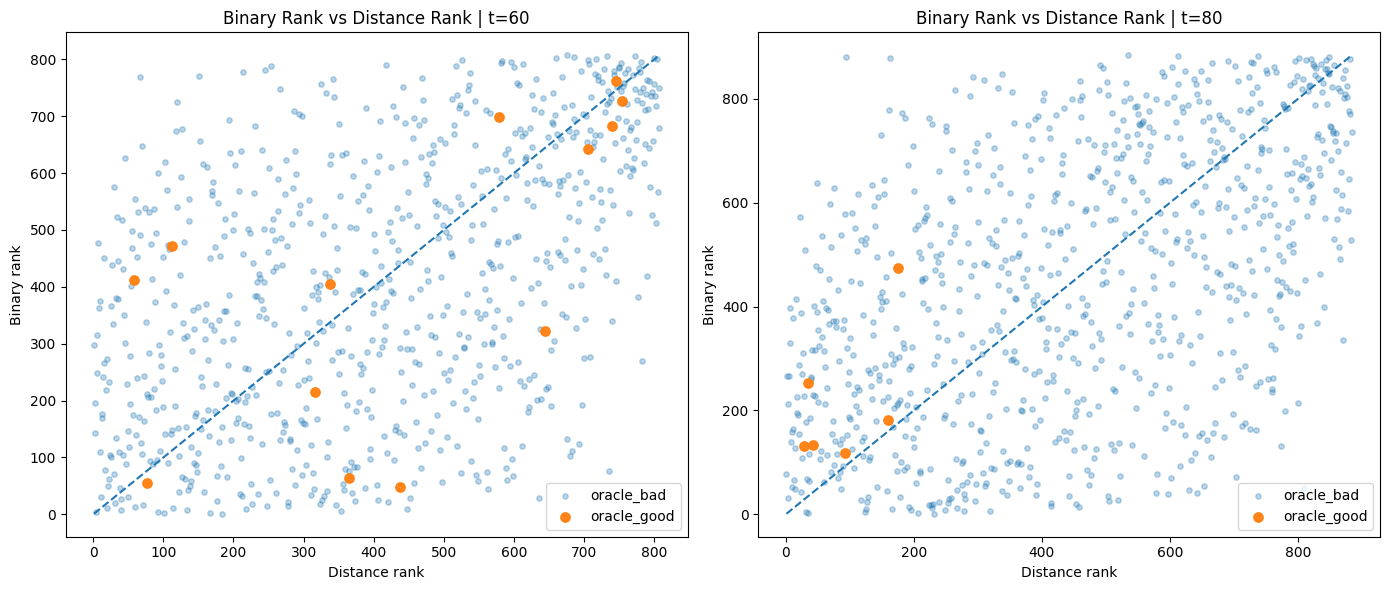

,t,pearson_score_correlation,pearson_p_value,spearman_rank_correlation,spearman_p_value
0,60,0.363126,1.471068e-26,0.487002,2.732425e-49
1,80,0.358206,3.724014e-28,0.490483,1.073990e-54


In [12]:

fig,axes=plt.subplots(1,2,figsize=(14,6))
corrows=[]
for ax,t in zip(axes,heldout_timesteps):
    d=comparison_df[comparison_df.t==t]; bad=d[~d.oracle_good]; good=d[d.oracle_good]
    ax.scatter(bad.distance_rank,bad.binary_rank,s=15,alpha=.3,label="oracle_bad")
    ax.scatter(good.distance_rank,good.binary_rank,s=45,alpha=.95,label="oracle_good")
    m=max(d.distance_rank.max(),d.binary_rank.max()); ax.plot([1,m],[1,m],"--")
    ax.set(title=f"Binary Rank vs Distance Rank | t={t}",xlabel="Distance rank",ylabel="Binary rank"); ax.legend()
    p,pp=pearsonr(d.binary_prob_good,-d.pred_dist); s,sp=spearmanr(d.binary_prob_good,-d.pred_dist)
    corrows.append({"t":t,"pearson_score_correlation":p,"pearson_p_value":pp,"spearman_rank_correlation":s,"spearman_p_value":sp})
plt.tight_layout(); plt.show()
correlation_df=pd.DataFrame(corrows)
correlation_df


# Step 10 — Top-k Candidate Overlap


In [13]:

keys=["t","z","y","x"]; topk_values=[25,50,100,200]; rows=[]
for t in heldout_timesteps:
    d=comparison_df[comparison_df.t==t]
    for k in topk_values:
        a=set(map(tuple,d.nsmallest(k,"binary_rank")[keys].to_numpy()))
        b=set(map(tuple,d.nsmallest(k,"distance_rank")[keys].to_numpy()))
        inter=a&b; union=a|b
        rows.append({"t":t,"top_k":k,"shared":len(inter),"classifier_only":len(a-b),"regressor_only":len(b-a),"union_size":len(union),"jaccard_overlap":len(inter)/len(union) if union else np.nan})
topk_overlap_df=pd.DataFrame(rows)
topk_overlap_df


,t,top_k,shared,classifier_only,regressor_only,union_size,jaccard_overlap
0,60,25,2,23,23,48,0.041667
1,60,50,9,41,41,91,0.098901
2,60,100,20,80,80,180,0.111111
3,60,200,81,119,119,319,0.253918
4,80,25,0,25,25,50,0.000000
5,80,50,5,45,45,95,0.052632
6,80,100,17,83,83,183,0.092896
7,80,200,74,126,126,326,0.226994


# Step 11 — Oracle-Good Recovery Overlap


In [14]:

rows=[]
for t in heldout_timesteps:
    g=comparison_df[(comparison_df.t==t)&(comparison_df.oracle_good)]
    allg=set(map(tuple,g[keys].to_numpy()))
    for k in topk_values:
        a=set(map(tuple,g[g.binary_rank<=k][keys].to_numpy()))
        b=set(map(tuple,g[g.distance_rank<=k][keys].to_numpy()))
        rows.append({"t":t,"top_k":k,"num_oracle_good":len(allg),"both":len(a&b),"classifier_only":len(a-b),"regressor_only":len(b-a),"neither":len(allg-(a|b)),"union_recovered":len(a|b)})
oracle_overlap_df=pd.DataFrame(rows)
oracle_overlap_df


,t,top_k,num_oracle_good,both,classifier_only,regressor_only,neither,union_recovered
0,60,25,13,0,0,0,13,0
1,60,50,13,0,1,0,12,1
2,60,100,13,1,2,1,9,4
3,60,200,13,1,2,2,8,5
4,80,25,6,0,0,0,6,0
5,80,50,6,0,0,3,3,3
6,80,100,6,0,0,4,2,4
7,80,200,6,4,0,2,0,6


# Step 12 — Oracle-Good Retention Curves


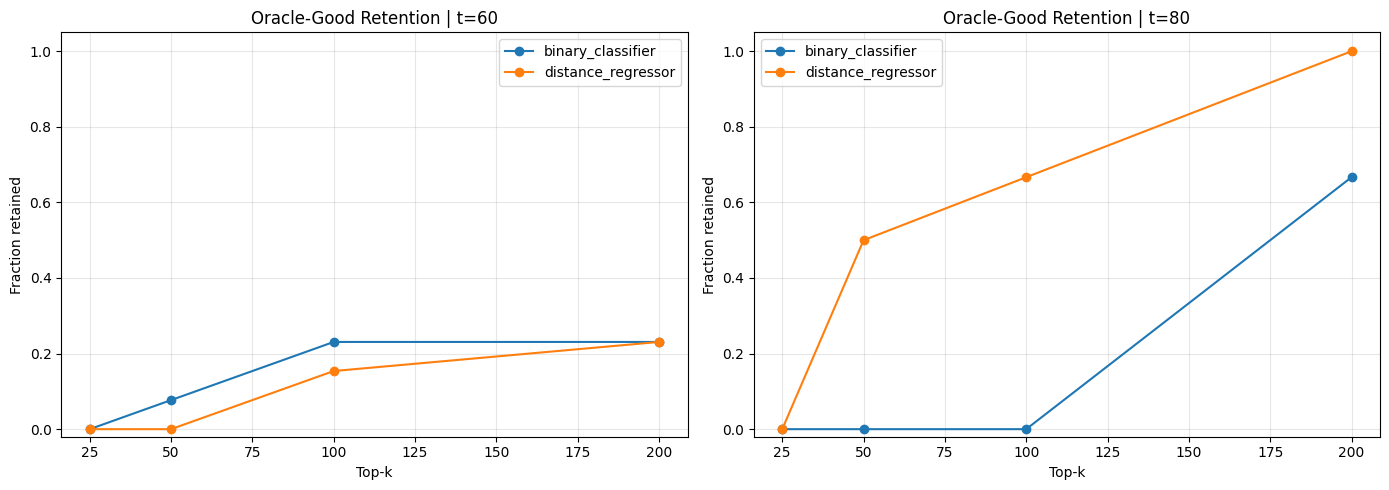

In [15]:

rows=[]
for t in heldout_timesteps:
    g=comparison_df[(comparison_df.t==t)&(comparison_df.oracle_good)]
    for k in topk_values:
        rows += [{"t":t,"top_k":k,"model":"binary_classifier","fraction_retained":(g.binary_rank<=k).mean()},
                 {"t":t,"top_k":k,"model":"distance_regressor","fraction_retained":(g.distance_rank<=k).mean()}]
retention_df=pd.DataFrame(rows)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,t in zip(axes,heldout_timesteps):
    sub=retention_df[retention_df.t==t]
    for name,grp in sub.groupby("model"):
        ax.plot(grp.top_k,grp.fraction_retained,marker="o",label=name)
    ax.set(title=f"Oracle-Good Retention | t={t}",xlabel="Top-k",ylabel="Fraction retained",ylim=(-.02,1.05)); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()


# Step 13 — Identify Model-Only Successes at Top 100


In [16]:

selected_top_k=100; parts=[]
for t in heldout_timesteps:
    g=comparison_df[(comparison_df.t==t)&(comparison_df.oracle_good)].copy()
    g["recovery_group"]=np.select([
        (g.binary_rank<=selected_top_k)&(g.distance_rank<=selected_top_k),
        (g.binary_rank<=selected_top_k)&(g.distance_rank>selected_top_k),
        (g.binary_rank>selected_top_k)&(g.distance_rank<=selected_top_k)],
        ["both","classifier_only","regressor_only"],default="neither")
    parts.append(g)
model_only_df=pd.concat(parts,ignore_index=True)
display(model_only_df[["t","z","y","x","nearest_gt_dist","binary_rank","distance_rank","binary_prob_good","pred_dist","recovery_group"]].sort_values(["t","recovery_group"]))
recovery_group_summary=model_only_df.groupby(["t","recovery_group"]).size().unstack(fill_value=0)
recovery_group_summary


,t,z,y,x,nearest_gt_dist,binary_rank,distance_rank,binary_prob_good,pred_dist,recovery_group
7,60,24.0,204.0,71.0,5.099020,55,76,0.323078,18.577214,both
8,60,25.0,215.0,110.0,4.242641,64,364,0.298209,19.305225,classifier_only
11,60,16.0,195.0,63.0,4.898979,48,438,0.335182,19.397680,classifier_only
0,60,42.0,157.0,67.0,2.000000,642,706,0.018366,19.758094,neither
1,60,41.0,156.0,64.0,4.358899,698,578,0.010814,19.582560,neither
2,60,25.0,210.0,78.0,4.242641,682,739,0.012385,19.801371,neither
3,60,47.0,66.0,164.0,5.477226,761,745,0.003251,19.815756,neither
4,60,43.0,163.0,70.0,5.099020,727,754,0.007526,19.833483,neither
5,60,39.0,158.0,62.0,5.916080,323,644,0.113090,19.672009,neither
6,60,34.0,47.0,222.0,5.830952,405,338,0.076869,19.268803,neither


recovery_group,both,classifier_only,neither,regressor_only
t,,,,
60,1,2,9,1
80,0,0,2,4


# Step 14 — Compare Features of Model-Only Successes


In [17]:

diagnostic_features=["bright_fraction","patch_com_offset","mass_center_offset_3d","slice_mean_std","center_slice_minus_neighbor_mean","peak_to_mean_ratio","patch_std","z_line_std","center_over_vol_mean","local_contrast"]
feature_group_summary=model_only_df.groupby(["t","recovery_group"])[diagnostic_features].mean()
feature_group_summary


bright_fraction  patch_com_offset  mass_center_offset_3d  \
t  recovery_group                                                              
60 both                    0.486420          0.172035               0.247170   
   classifier_only         0.525926          0.109102               0.150224   
   neither                 0.525652          0.112562               0.212851   
   regressor_only          0.456790          0.177221               0.174285   
80 neither                 0.534321          0.152668               1.034367   
   regressor_only          0.549383          0.125577               0.150562   

                    slice_mean_std  center_slice_minus_neighbor_mean  \
t  recovery_group                                                      
60 both                 204.350297                         69.506173   
   classifier_only      124.598423                         84.657407   
   neither              230.227157                        116.287380   
   regressor_only       127.476977                        107.512346   
80 neither              111.389451                         75.583951   
   regressor_only        60.318586                         23.427469   

                    peak_to_mean_ratio   patch_std  z_line_std  \
t  recovery_group                                                
60 both                       1.514351  224.838952  260.644279   
   classifier_only            1.321462  136.723225  133.748168   
   neither                    1.376843  201.706598  285.480422   
   regressor_only             1.414245  177.621119  203.365090   
80 neither                    1.270475  172.495591  144.378237   
   regressor_only             1.247066  144.052480   74.583002   

                    center_over_vol_mean  local_contrast  
t  recovery_group                                         
60 both                         1.204643      474.037037  
   classifier_only              1.265113      217.111111  
   neither                      1.305737      339.702332  
   regressor_only               1.414245      251.185185  
80 neither                      1.176143      262.218519  
   regressor_only               1.177267      231.055556

# Step 15 — Visualize Model-Only Oracle-Good Successes


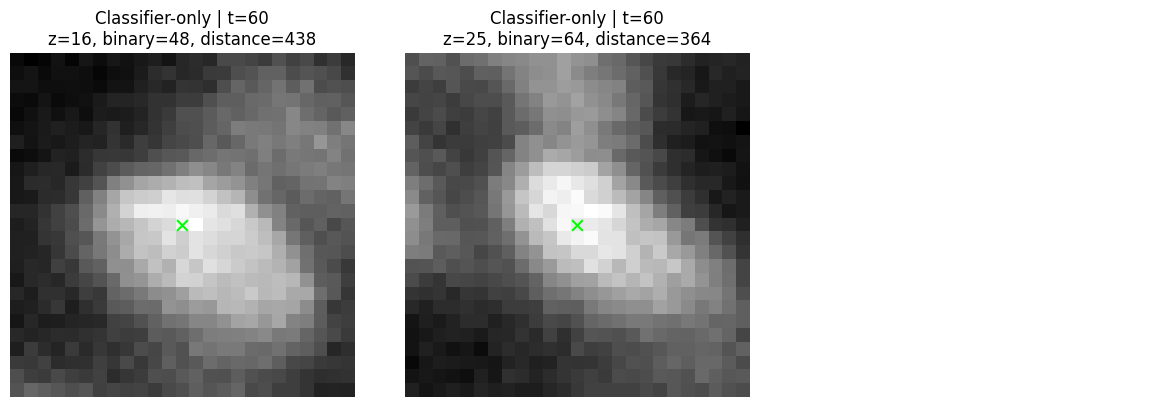

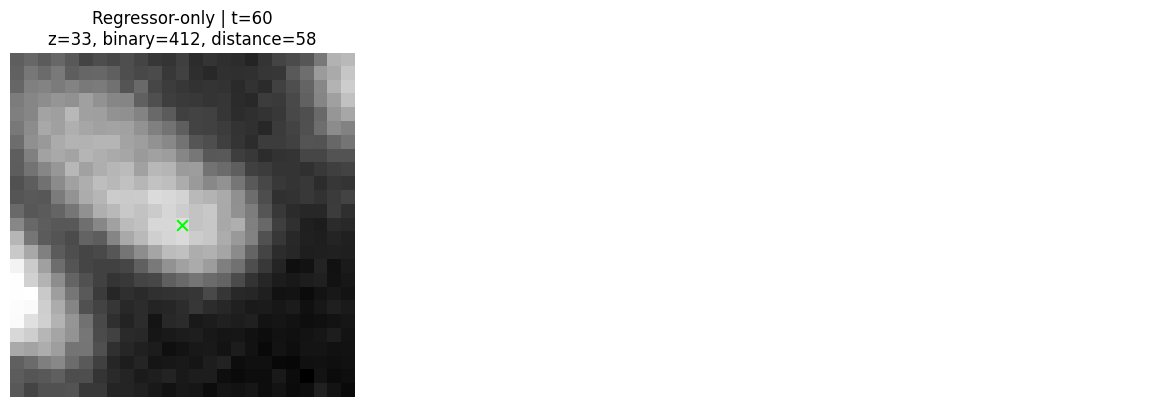

No examples for Classifier-only | t=80


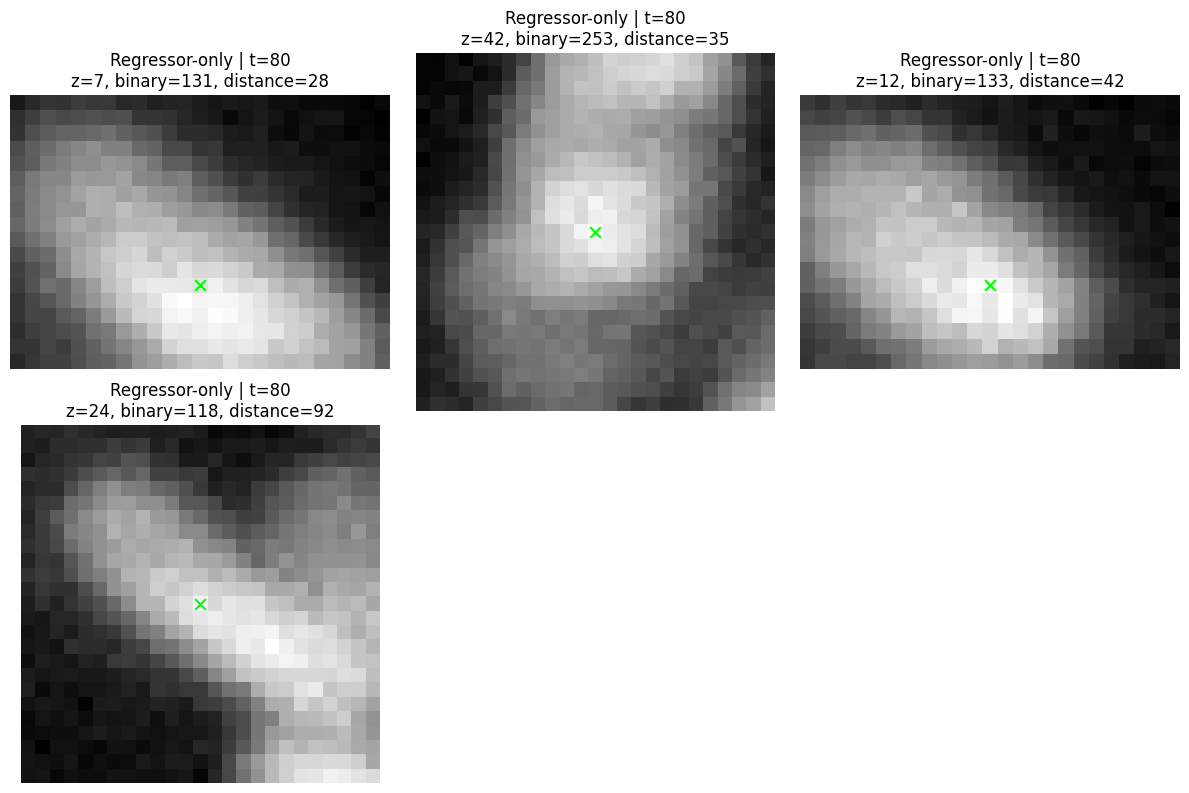

In [18]:

def show_gallery(frame,df,title,patch_radius=12,max_items=6):
    d=df.head(max_items)
    if len(d)==0:
        print("No examples for",title); return
    cols=3; rows=int(np.ceil(len(d)/cols)); fig,axes=plt.subplots(rows,cols,figsize=(4*cols,4*rows)); axes=np.array(axes).reshape(-1)
    for ax,(_,r) in zip(axes,d.iterrows()):
        z,y,x=int(r.z),int(r.y),int(r.x); y0=max(0,y-patch_radius); y1=min(frame.shape[1],y+patch_radius+1); x0=max(0,x-patch_radius); x1=min(frame.shape[2],x+patch_radius+1)
        ax.imshow(frame[z,y0:y1,x0:x1],cmap="gray"); ax.scatter([x-x0],[y-y0],marker="x",s=60,c="lime")
        ax.set_title(f"{title}\nz={z}, binary={int(r.binary_rank)}, distance={int(r.distance_rank)}"); ax.axis("off")
    for ax in axes[len(d):]: ax.axis("off")
    plt.tight_layout(); plt.show()

for t in heldout_timesteps:
    frame=heldout_frames[t]
    show_gallery(frame,model_only_df[(model_only_df.t==t)&(model_only_df.recovery_group=="classifier_only")].sort_values("binary_rank"),f"Classifier-only | t={t}")
    show_gallery(frame,model_only_df[(model_only_df.t==t)&(model_only_df.recovery_group=="regressor_only")].sort_values("distance_rank"),f"Regressor-only | t={t}")


# Step 16 — Compare Top-k Detector Metrics


In [19]:

rows=[]
for t in heldout_timesteps:
    d=comparison_df[comparison_df.t==t]; gtpts=heldout_gt[t][["z","y","x"]].to_numpy()
    for name,col in [("binary_classifier","binary_rank"),("distance_regressor","distance_rank")]:
        for k in topk_values:
            kept=d.nsmallest(k,col); result=evaluate_predictions(gtpts,kept[["z","y","x"]].to_numpy(),oracle_radius)
            result.update({"t":t,"model":name,"top_k":k}); rows.append(result)
model_metric_df=pd.DataFrame(rows)
model_metric_df


,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,t,model,top_k
0,9,25,0,9,0,25,0.000000,0.000,60,binary_classifier,25
1,9,50,1,8,1,49,0.111111,0.020,60,binary_classifier,50
2,9,100,3,6,3,97,0.333333,0.030,60,binary_classifier,100
3,9,200,3,6,3,197,0.333333,0.015,60,binary_classifier,200
4,9,25,0,9,0,25,0.000000,0.000,60,distance_regressor,25
5,9,50,0,9,0,50,0.000000,0.000,60,distance_regressor,50
6,9,100,2,7,2,98,0.222222,0.020,60,distance_regressor,100
7,9,200,3,6,3,197,0.333333,0.015,60,distance_regressor,200
8,6,25,0,6,0,25,0.000000,0.000,80,binary_classifier,25
9,6,50,0,6,0,50,0.000000,0.000,80,binary_classifier,50


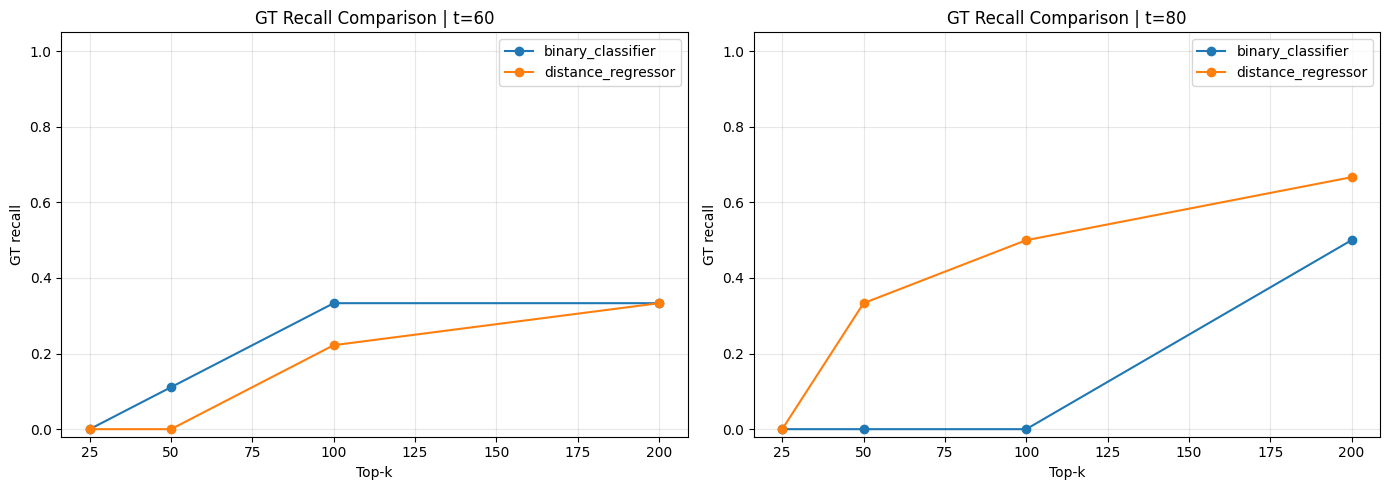

In [20]:

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,t in zip(axes,heldout_timesteps):
    sub=model_metric_df[model_metric_df.t==t]
    for name,grp in sub.groupby("model"):
        ax.plot(grp.top_k,grp.gt_recall,marker="o",label=name)
    ax.set(title=f"GT Recall Comparison | t={t}",xlabel="Top-k",ylabel="GT recall",ylim=(-.02,1.05)); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()


# Step 17 — Ensemble-Readiness Decision Table


In [21]:

rows=[]
for t in heldout_timesteps:
    corr=correlation_df[correlation_df.t==t].iloc[0]
    o=oracle_overlap_df[(oracle_overlap_df.t==t)&(oracle_overlap_df.top_k==100)].iloc[0]
    best=max(o.both+o.classifier_only,o.both+o.regressor_only); gain=o.union_recovered-best
    rows.append({"t":t,"spearman_rank_correlation":corr.spearman_rank_correlation,"classifier_only_good_at_100":o.classifier_only,"regressor_only_good_at_100":o.regressor_only,"union_good_at_100":o.union_recovered,"union_gain_over_best_single":gain,"ensemble_signal":"strong" if gain>0 and abs(corr.spearman_rank_correlation)<.90 else "weak_or_unclear"})
ensemble_readiness_df=pd.DataFrame(rows)
ensemble_readiness_df


,t,spearman_rank_correlation,classifier_only_good_at_100,regressor_only_good_at_100,union_good_at_100,union_gain_over_best_single,ensemble_signal
0,60,0.487002,2,1,4,1,strong
1,80,0.490483,0,4,4,0,weak_or_unclear


# Step 25 — Build the Ensemble Rankings

The baseline rankings already exist in `comparison_df`:

- `binary_rank`
- `distance_rank`

This step adds:

- `average_normalized_rank`
- `rrf_rank`
- `weighted_rank`

## Rank direction

All final rank columns follow the same rule:

```text
rank 1 = best candidate
```


In [22]:

rrf_k = 60
binary_weight = 0.40
distance_weight = 0.60

ensemble_parts = []

for t in heldout_timesteps:
    d = comparison_df[comparison_df.t == t].copy()
    n = len(d)

    if n <= 1:
        d["binary_normalized_rank"] = 0.0
        d["distance_normalized_rank"] = 0.0
    else:
        d["binary_normalized_rank"] = (d["binary_rank"] - 1) / (n - 1)
        d["distance_normalized_rank"] = (d["distance_rank"] - 1) / (n - 1)

    # Equal-weight average normalized rank: smaller is better.
    d["average_normalized_score"] = (
        0.5 * d["binary_normalized_rank"]
        + 0.5 * d["distance_normalized_rank"]
    )
    d["average_normalized_rank"] = (
        d["average_normalized_score"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    # Reciprocal Rank Fusion: larger score is better.
    d["rrf_score"] = (
        1.0 / (rrf_k + d["binary_rank"])
        + 1.0 / (rrf_k + d["distance_rank"])
    )
    d["rrf_rank"] = (
        d["rrf_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    # Weighted normalized rank: smaller is better.
    d["weighted_score"] = (
        binary_weight * d["binary_normalized_rank"]
        + distance_weight * d["distance_normalized_rank"]
    )
    d["weighted_rank"] = (
        d["weighted_score"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    ensemble_parts.append(d)

ensemble_df = pd.concat(ensemble_parts, ignore_index=True)

display(
    ensemble_df[[
        "t", "z", "y", "x", "oracle_good",
        "binary_rank", "distance_rank",
        "average_normalized_rank", "rrf_rank", "weighted_rank"
    ]].head()
)


,t,z,y,x,oracle_good,binary_rank,distance_rank,average_normalized_rank,rrf_rank,weighted_rank
0,60,62.0,92.0,224.0,False,571,105,330,231,268
1,60,63.0,132.0,245.0,False,775,537,689,681,668
2,60,62.0,59.0,235.0,False,631,339,523,515,484
3,60,37.0,223.0,15.0,False,759,604,711,708,695
4,60,45.0,0.0,64.0,False,785,749,789,789,785


# Step 26 — Define the Ranking Methods

This dictionary lets every evaluation cell treat the baselines and ensembles in the same way.


In [23]:

ranking_methods = {
    "binary_classifier": "binary_rank",
    "distance_regressor": "distance_rank",
    "average_normalized_rank": "average_normalized_rank",
    "rrf": "rrf_rank",
    "weighted_rank_fusion": "weighted_rank",
}

topk_values = [25, 50, 100, 200]

for method_name, rank_column in ranking_methods.items():
    print(f"{method_name}: {rank_column}")


binary_classifier: binary_rank
distance_regressor: distance_rank
average_normalized_rank: average_normalized_rank
rrf: rrf_rank
weighted_rank_fusion: weighted_rank


# Step 27 — Evaluate All Ranking Methods

For every timepoint, method, and top-k cutoff, this cell calculates:

- GT recall
- precision-like score
- matched and unmatched predictions
- oracle-good candidates retained
- candidate compression ratio


In [24]:

ensemble_result_rows = []

for t in heldout_timesteps:
    d = ensemble_df[ensemble_df.t == t].copy()
    gt_points = heldout_gt[t][["z", "y", "x"]].to_numpy()
    full_pool_size = len(d)
    total_oracle_good = int(d.oracle_good.sum())

    for method_name, rank_column in ranking_methods.items():
        for top_k in topk_values:
            kept = d.nsmallest(min(top_k, len(d)), rank_column).copy()
            pred_points = kept[["z", "y", "x"]].to_numpy()

            result = evaluate_predictions(
                gt_points,
                pred_points,
                oracle_radius,
            )

            result.update({
                "t": t,
                "method": method_name,
                "top_k": top_k,
                "full_pool_size": full_pool_size,
                "compression_ratio": (
                    full_pool_size / len(kept)
                    if len(kept) > 0 else np.nan
                ),
                "total_oracle_good": total_oracle_good,
                "oracle_good_retained": int(kept.oracle_good.sum()),
                "oracle_good_retention": (
                    kept.oracle_good.sum() / total_oracle_good
                    if total_oracle_good > 0 else np.nan
                ),
            })
            ensemble_result_rows.append(result)

ensemble_results_df = pd.DataFrame(ensemble_result_rows)
ensemble_results_df


,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,t,method,top_k,full_pool_size,compression_ratio,total_oracle_good,oracle_good_retained,oracle_good_retention
0,9,25,0,9,0,25,0.000000,0.000,60,binary_classifier,25,807,32.280,13,0,0.000000
1,9,50,1,8,1,49,0.111111,0.020,60,binary_classifier,50,807,16.140,13,1,0.076923
2,9,100,3,6,3,97,0.333333,0.030,60,binary_classifier,100,807,8.070,13,3,0.230769
3,9,200,3,6,3,197,0.333333,0.015,60,binary_classifier,200,807,4.035,13,3,0.230769
4,9,25,0,9,0,25,0.000000,0.000,60,distance_regressor,25,807,32.280,13,0,0.000000
5,9,50,0,9,0,50,0.000000,0.000,60,distance_regressor,50,807,16.140,13,0,0.000000
6,9,100,2,7,2,98,0.222222,0.020,60,distance_regressor,100,807,8.070,13,2,0.153846
7,9,200,3,6,3,197,0.333333,0.015,60,distance_regressor,200,807,4.035,13,3,0.230769
8,9,25,1,8,1,24,0.111111,0.040,60,average_normalized_rank,25,807,32.280,13,1,0.076923
9,9,50,1,8,1,49,0.111111,0.020,60,average_normalized_rank,50,807,16.140,13,1,0.076923


# Step 28 — Compact Ensemble Comparison Table


In [25]:

ensemble_comparison_df = (
    ensemble_results_df[[
        "t", "method", "top_k", "num_pred",
        "gt_detected", "gt_recall", "pred_precision_like",
        "oracle_good_retained", "oracle_good_retention",
        "compression_ratio"
    ]]
    .sort_values(
        ["t", "top_k", "gt_recall", "pred_precision_like"],
        ascending=[True, True, False, False],
    )
)

display(ensemble_comparison_df)


,t,method,top_k,num_pred,gt_detected,gt_recall,pred_precision_like,oracle_good_retained,oracle_good_retention,compression_ratio
8,60,average_normalized_rank,25,25,1,0.111111,0.040,1,0.076923,32.280
16,60,weighted_rank_fusion,25,25,1,0.111111,0.040,1,0.076923,32.280
0,60,binary_classifier,25,25,0,0.000000,0.000,0,0.000000,32.280
4,60,distance_regressor,25,25,0,0.000000,0.000,0,0.000000,32.280
12,60,rrf,25,25,0,0.000000,0.000,0,0.000000,32.280
1,60,binary_classifier,50,50,1,0.111111,0.020,1,0.076923,16.140
9,60,average_normalized_rank,50,50,1,0.111111,0.020,1,0.076923,16.140
13,60,rrf,50,50,1,0.111111,0.020,1,0.076923,16.140
17,60,weighted_rank_fusion,50,50,1,0.111111,0.020,1,0.076923,16.140
5,60,distance_regressor,50,50,0,0.000000,0.000,0,0.000000,16.140


# Step 29 — GT Recall Comparison

The individual baselines remain on the graph so the ensemble must prove that it adds value.


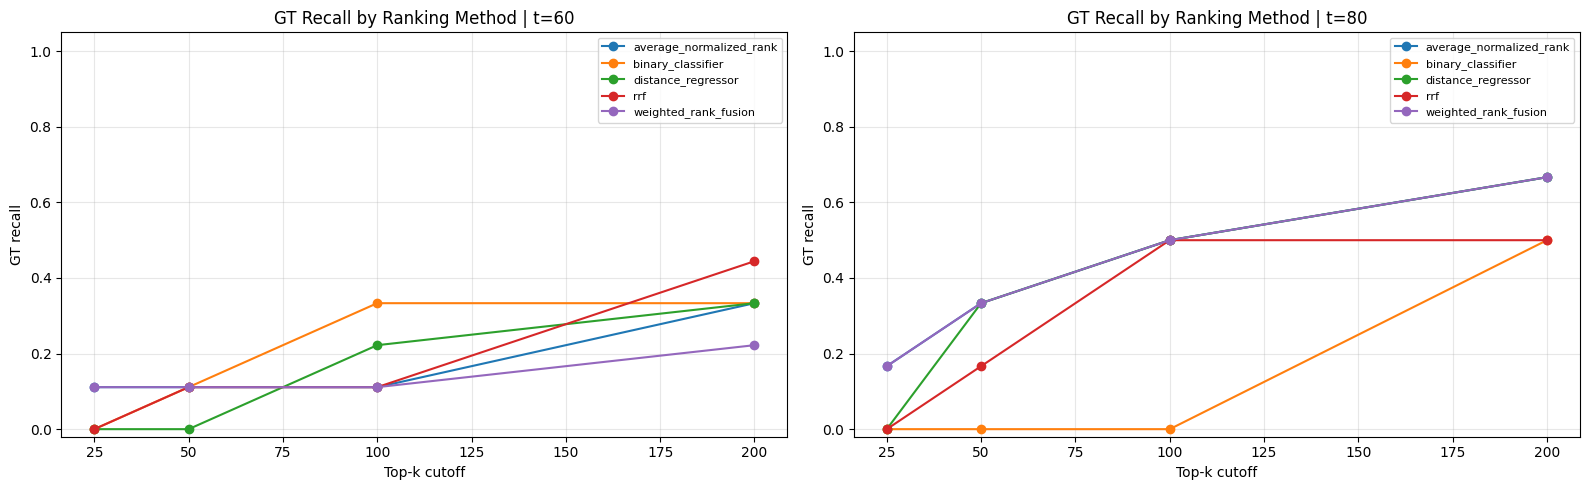

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, t in zip(axes, heldout_timesteps):
    sub = ensemble_results_df[ensemble_results_df.t == t]

    for method_name, group in sub.groupby("method"):
        group = group.sort_values("top_k")
        ax.plot(
            group.top_k,
            group.gt_recall,
            marker="o",
            label=method_name,
        )

    ax.set_title(f"GT Recall by Ranking Method | t={t}")
    ax.set_xlabel("Top-k cutoff")
    ax.set_ylabel("GT recall")
    ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Step 30 — Precision-like Comparison


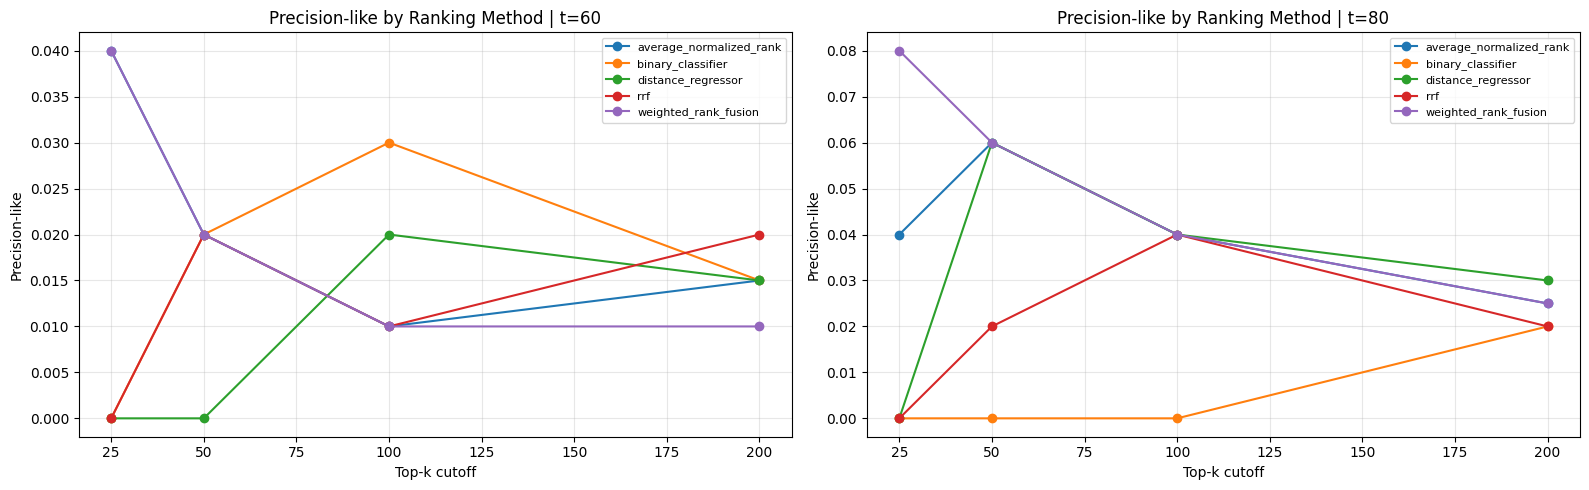

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, t in zip(axes, heldout_timesteps):
    sub = ensemble_results_df[ensemble_results_df.t == t]

    for method_name, group in sub.groupby("method"):
        group = group.sort_values("top_k")
        ax.plot(
            group.top_k,
            group.pred_precision_like,
            marker="o",
            label=method_name,
        )

    ax.set_title(f"Precision-like by Ranking Method | t={t}")
    ax.set_xlabel("Top-k cutoff")
    ax.set_ylabel("Precision-like")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Step 31 — Oracle-Good Retention Comparison

This metric directly measures whether a method keeps the candidate points that are close to GT cells.


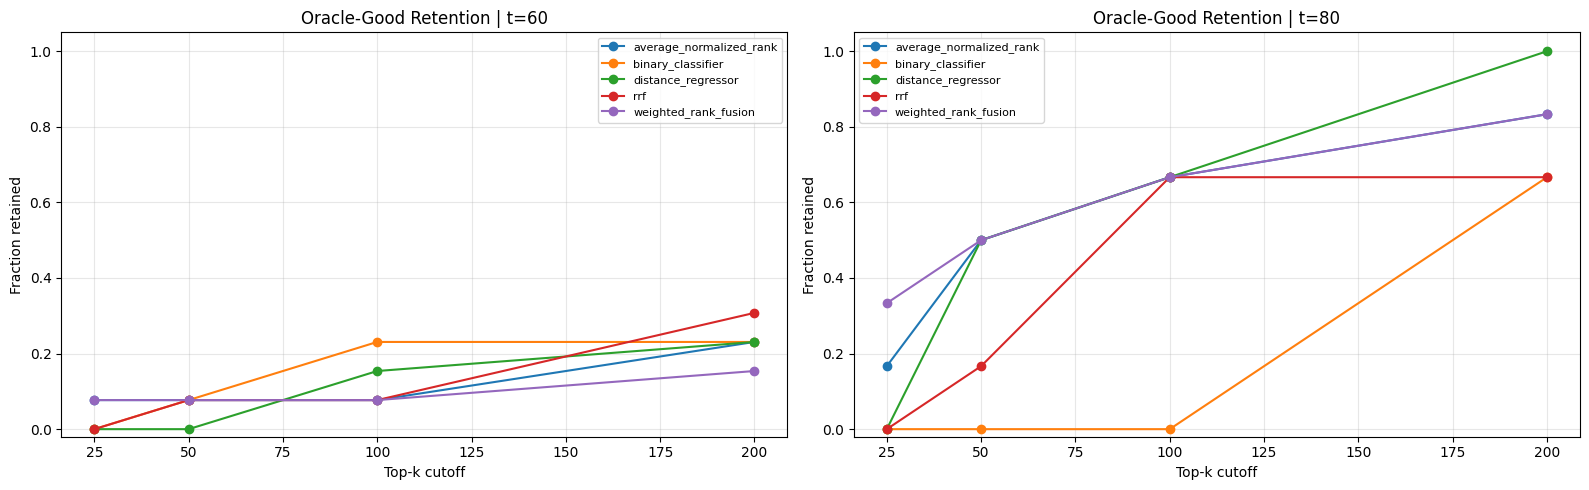

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, t in zip(axes, heldout_timesteps):
    sub = ensemble_results_df[ensemble_results_df.t == t]

    for method_name, group in sub.groupby("method"):
        group = group.sort_values("top_k")
        ax.plot(
            group.top_k,
            group.oracle_good_retention,
            marker="o",
            label=method_name,
        )

    ax.set_title(f"Oracle-Good Retention | t={t}")
    ax.set_xlabel("Top-k cutoff")
    ax.set_ylabel("Fraction retained")
    ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# Step 32 — Oracle-Good Rank Summary

This table compares the best, median, and worst oracle-good ranks under every method.


In [29]:

rank_summary_rows = []

for t in heldout_timesteps:
    d = ensemble_df[ensemble_df.t == t]
    good = d[d.oracle_good]

    for method_name, rank_column in ranking_methods.items():
        rank_summary_rows.append({
            "t": t,
            "method": method_name,
            "num_candidates": len(d),
            "num_oracle_good": len(good),
            "best_good_rank": good[rank_column].min(),
            "median_good_rank": good[rank_column].median(),
            "worst_good_rank": good[rank_column].max(),
            "good_in_top_25": int((good[rank_column] <= 25).sum()),
            "good_in_top_50": int((good[rank_column] <= 50).sum()),
            "good_in_top_100": int((good[rank_column] <= 100).sum()),
            "good_in_top_200": int((good[rank_column] <= 200).sum()),
        })

ensemble_rank_summary_df = pd.DataFrame(rank_summary_rows)
ensemble_rank_summary_df


,t,method,num_candidates,num_oracle_good,best_good_rank,median_good_rank,worst_good_rank,good_in_top_25,good_in_top_50,good_in_top_100,good_in_top_200
0,60,binary_classifier,807,13,48,412.0,761,0,1,3,3
1,60,distance_regressor,807,13,58,438.0,754,0,0,2,3
2,60,average_normalized_rank,807,13,21,377.0,776,1,1,1,3
3,60,rrf,807,13,46,433.0,776,0,1,1,4
4,60,weighted_rank_fusion,807,13,24,373.0,773,1,1,1,2
5,80,binary_classifier,884,6,118,157.0,474,0,0,0,4
6,80,distance_regressor,884,6,28,67.0,176,0,3,4,6
7,80,average_normalized_rank,884,6,23,67.0,297,1,3,4,5
8,80,rrf,884,6,39,88.0,312,0,1,4,4
9,80,weighted_rank_fusion,884,6,16,54.5,268,2,3,4,5


# Step 33 — Average Performance Across Held-Out Timepoints

A method should not be selected because it wins on only one held-out frame.

This table averages both held-out timepoints.


In [30]:

average_performance_df = (
    ensemble_results_df
    .groupby(["method", "top_k"], as_index=False)
    .agg(
        mean_gt_recall=("gt_recall", "mean"),
        mean_precision_like=("pred_precision_like", "mean"),
        mean_oracle_good_retention=("oracle_good_retention", "mean"),
        mean_compression_ratio=("compression_ratio", "mean"),
    )
    .sort_values(
        ["top_k", "mean_gt_recall", "mean_precision_like"],
        ascending=[True, False, False],
    )
)

average_performance_df


,method,top_k,mean_gt_recall,mean_precision_like,mean_oracle_good_retention,mean_compression_ratio
16,weighted_rank_fusion,25,0.138889,0.0600,0.205128,33.8200
0,average_normalized_rank,25,0.138889,0.0400,0.121795,33.8200
4,binary_classifier,25,0.000000,0.0000,0.000000,33.8200
8,distance_regressor,25,0.000000,0.0000,0.000000,33.8200
12,rrf,25,0.000000,0.0000,0.000000,33.8200
1,average_normalized_rank,50,0.222222,0.0400,0.288462,16.9100
17,weighted_rank_fusion,50,0.222222,0.0400,0.288462,16.9100
9,distance_regressor,50,0.166667,0.0300,0.250000,16.9100
13,rrf,50,0.138889,0.0200,0.121795,16.9100
5,binary_classifier,50,0.055556,0.0100,0.038462,16.9100


# Step 34 — Select the Best Method at Each Top-k

Selection order:

1. highest mean GT recall
2. highest mean precision-like score
3. highest mean oracle-good retention


In [31]:

overall_winner_rows = []

for top_k in topk_values:
    sub = (
        average_performance_df[average_performance_df.top_k == top_k]
        .sort_values(
            [
                "mean_gt_recall",
                "mean_precision_like",
                "mean_oracle_good_retention",
            ],
            ascending=False,
        )
    )

    winner = sub.iloc[0]

    overall_winner_rows.append({
        "top_k": top_k,
        "best_method": winner.method,
        "mean_gt_recall": winner.mean_gt_recall,
        "mean_precision_like": winner.mean_precision_like,
        "mean_oracle_good_retention": winner.mean_oracle_good_retention,
        "mean_compression_ratio": winner.mean_compression_ratio,
    })

overall_winner_df = pd.DataFrame(overall_winner_rows)
overall_winner_df


,top_k,best_method,mean_gt_recall,mean_precision_like,mean_oracle_good_retention,mean_compression_ratio
0,25,weighted_rank_fusion,0.138889,0.0600,0.205128,33.8200
1,50,average_normalized_rank,0.222222,0.0400,0.288462,16.9100
2,100,distance_regressor,0.361111,0.0300,0.410256,8.4550
3,200,distance_regressor,0.500000,0.0225,0.615385,4.2275


# Step 35 — Inspect Oracle-Good Ranks Across Every Method

This table shows whether an ensemble rescues specific oracle-good candidates that were ranked poorly by one or both baselines.


In [32]:

oracle_good_ensemble_comparison = (
    ensemble_df[ensemble_df.oracle_good][[
        "t", "z", "y", "x", "nearest_gt_dist",
        "binary_rank", "distance_rank",
        "average_normalized_rank", "rrf_rank", "weighted_rank"
    ]]
    .sort_values(["t", "rrf_rank"])
    .reset_index(drop=True)
)

oracle_good_ensemble_comparison


,t,z,y,x,nearest_gt_dist,binary_rank,distance_rank,average_normalized_rank,rrf_rank,weighted_rank
0,60,24.0,204.0,71.0,5.099020,55,76,21,46,24
1,60,16.0,195.0,63.0,4.898979,48,438,207,117,258
2,60,33.0,145.0,145.0,5.656854,412,58,199,134,145
3,60,25.0,215.0,110.0,4.242641,64,364,164,139,211
4,60,14.0,6.0,151.0,3.741657,472,113,268,230,232
5,60,27.0,219.0,112.0,2.449490,215,316,234,305,250
6,60,34.0,47.0,222.0,5.830952,405,338,377,433,373
7,60,39.0,158.0,62.0,5.916080,323,644,519,508,555
8,60,41.0,156.0,64.0,4.358899,698,578,674,677,663
9,60,42.0,157.0,67.0,2.000000,642,706,701,706,709


# Step 36 — Visualize Top-100 Predictions

Green `x` = selected candidate  
Red circle = GT location

To limit output, this cell visualizes the two baselines and RRF. Change `methods_to_plot` to include the other ensembles.


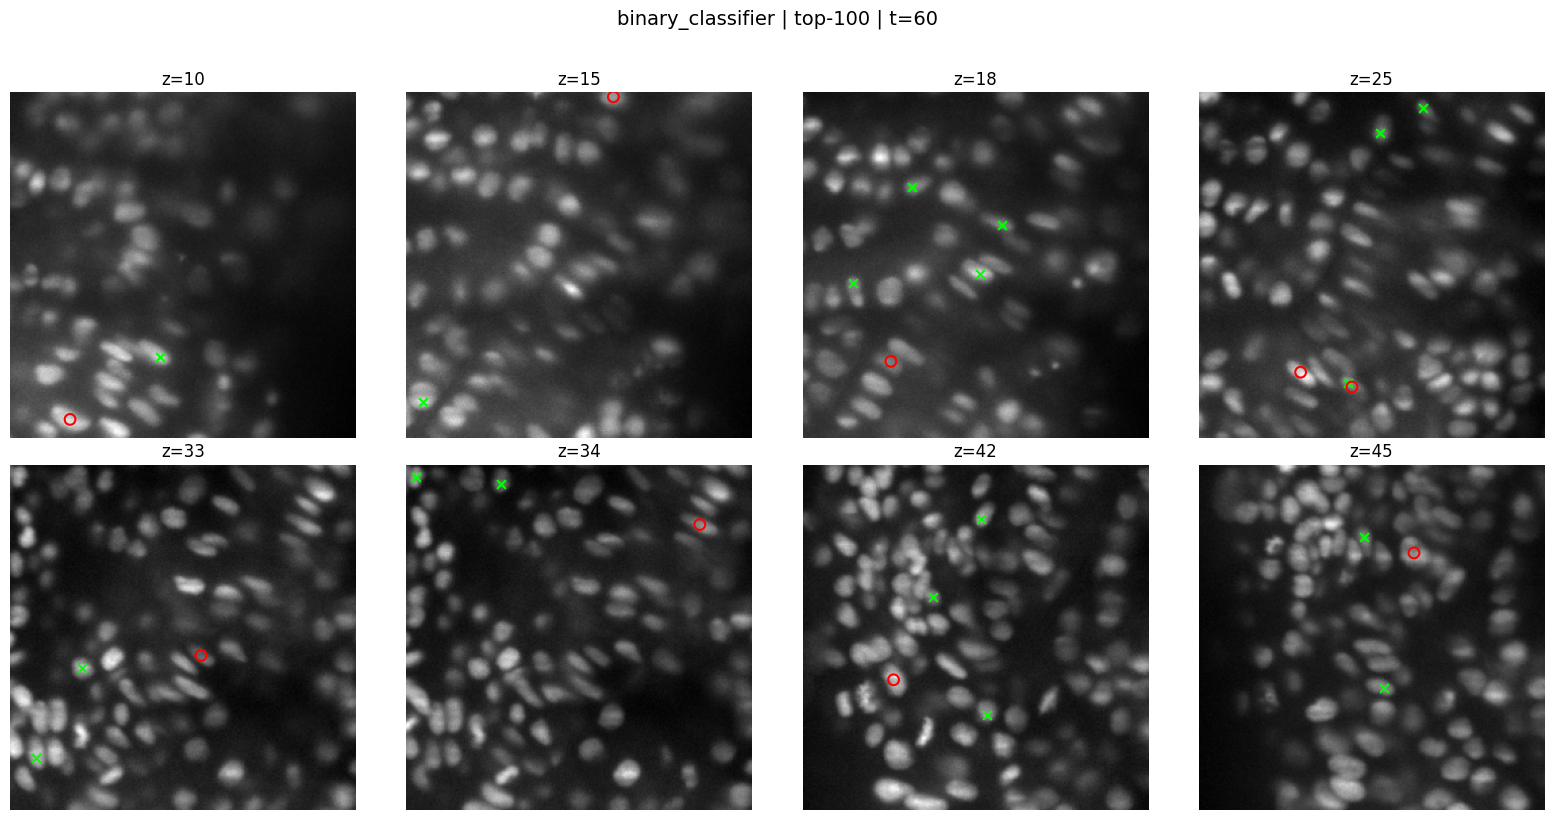

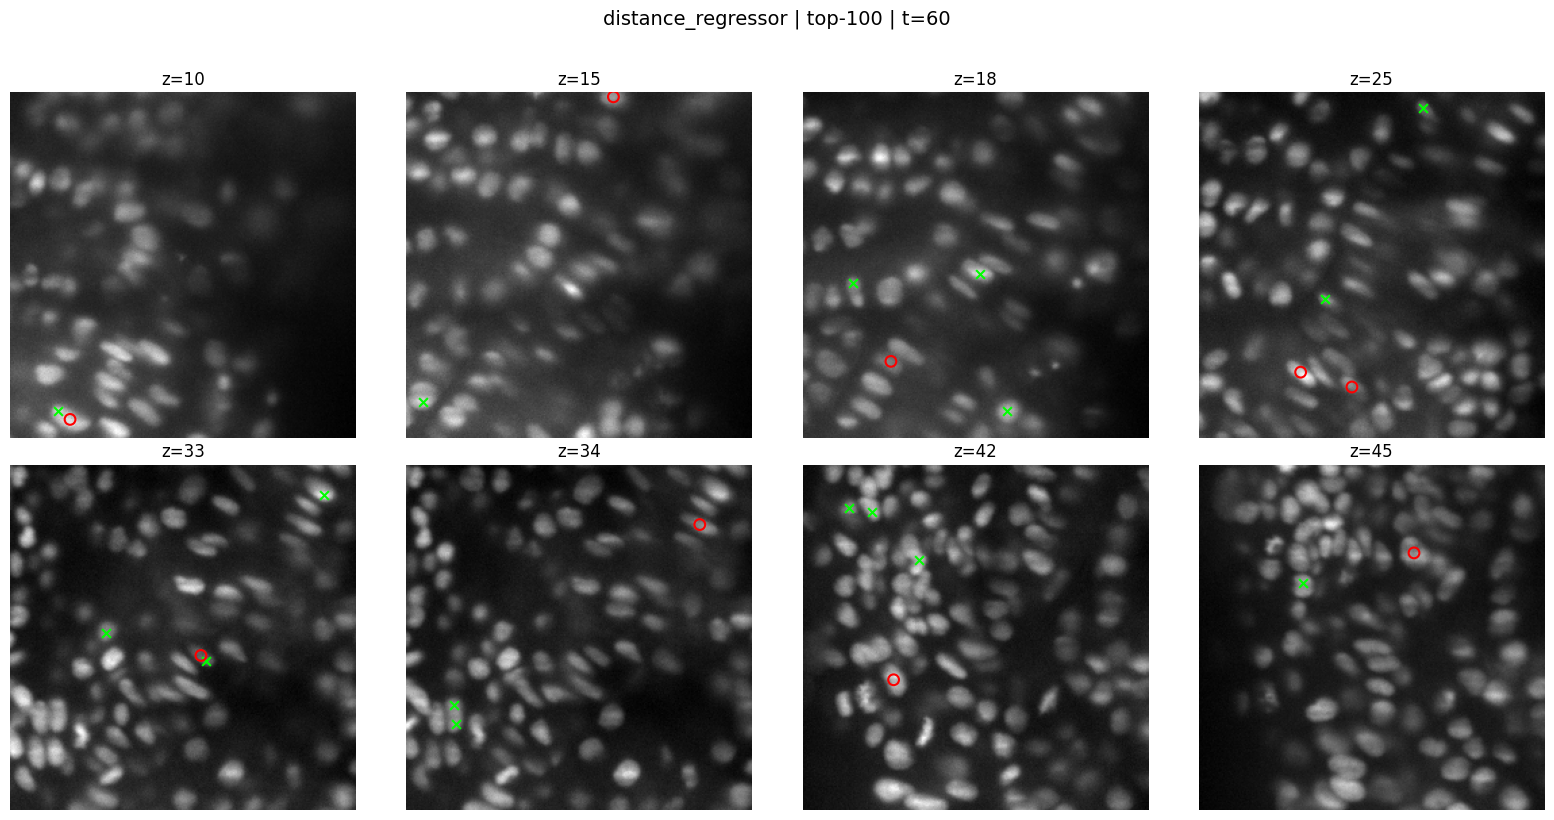

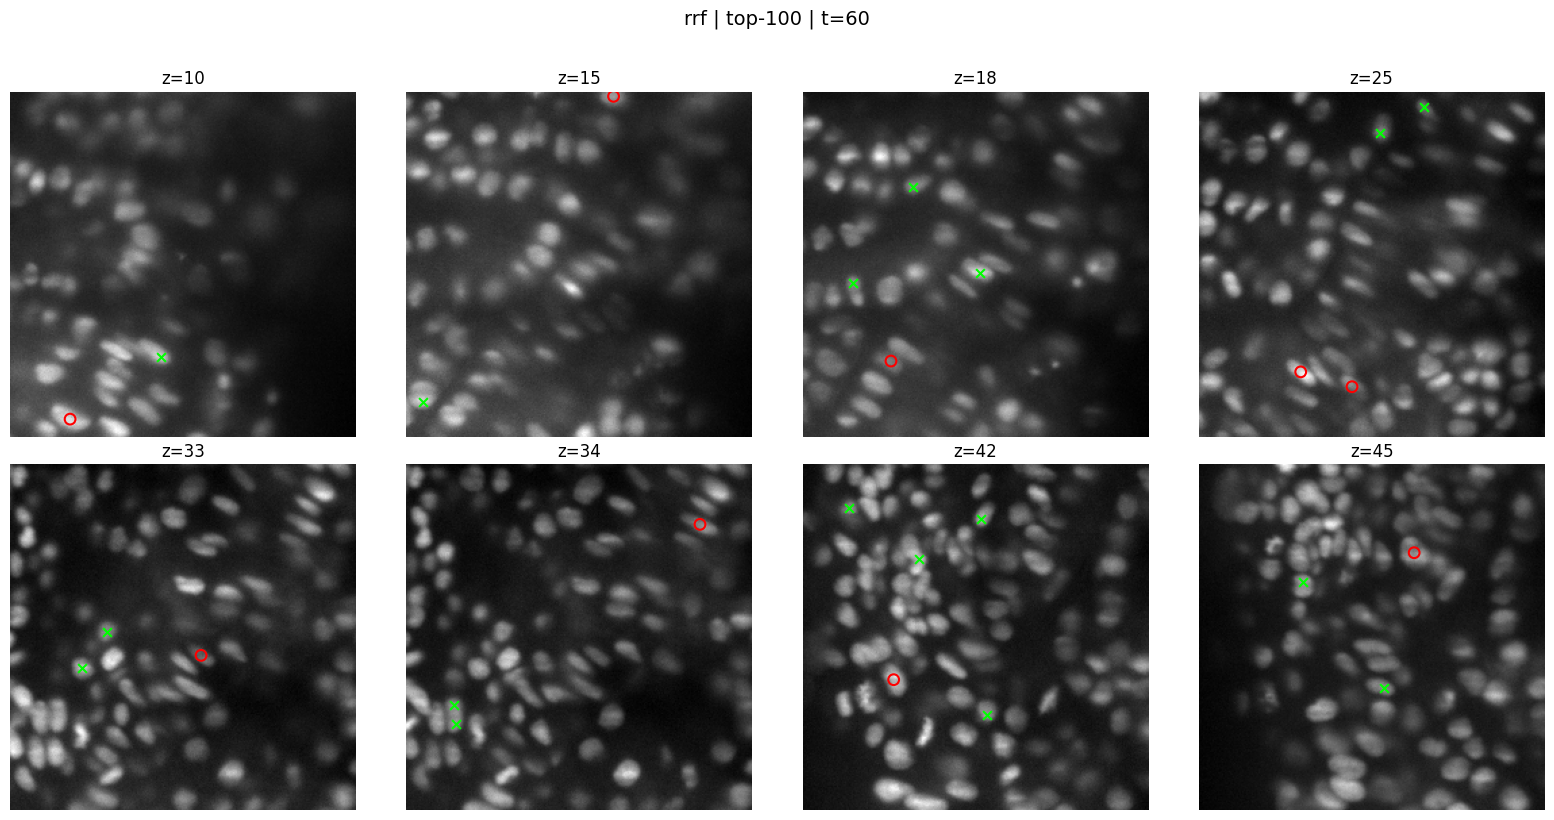

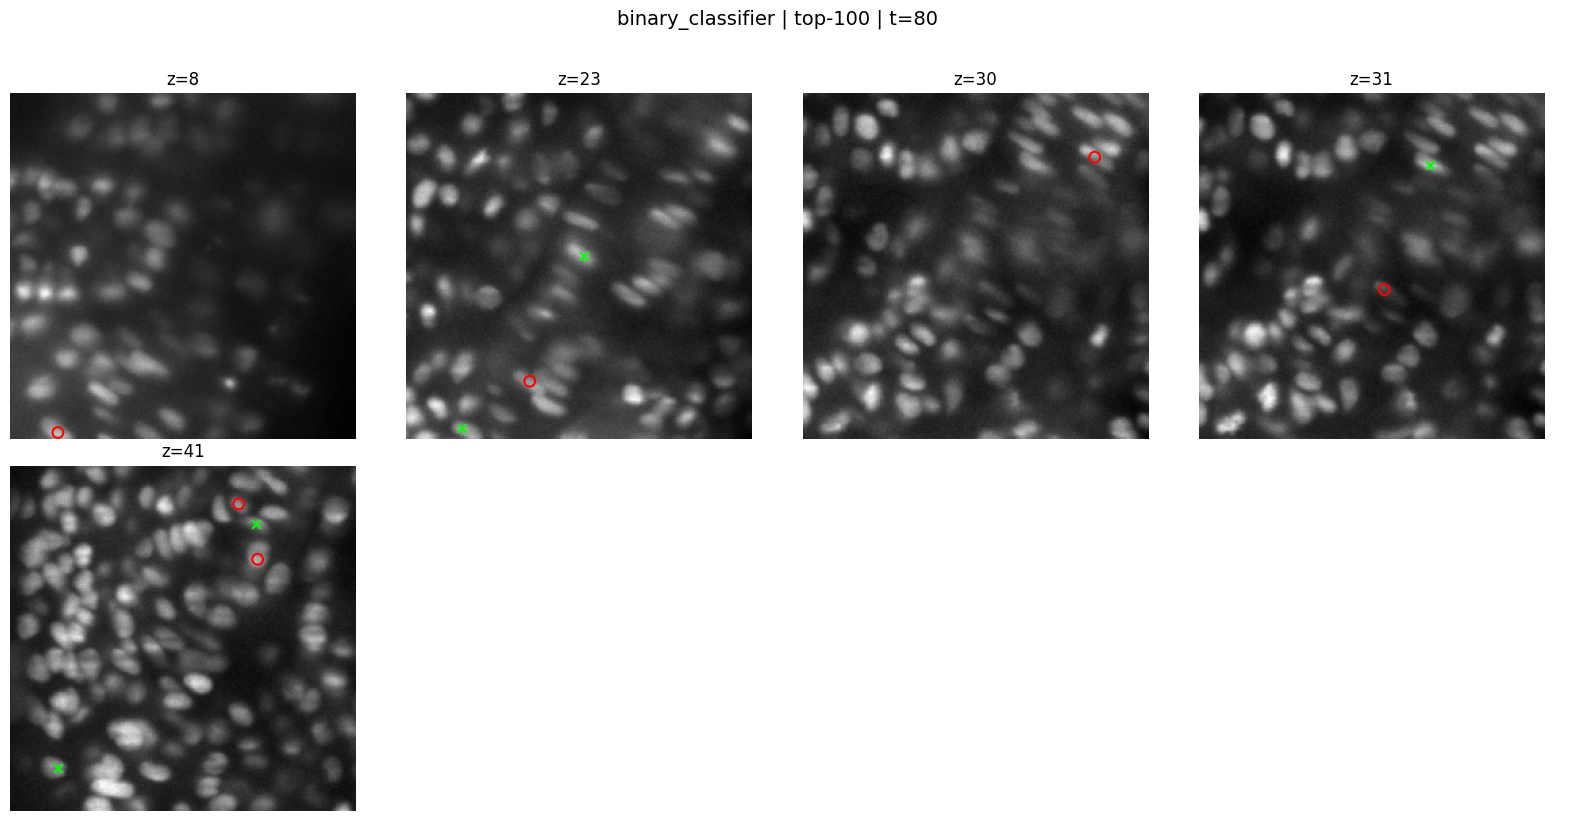

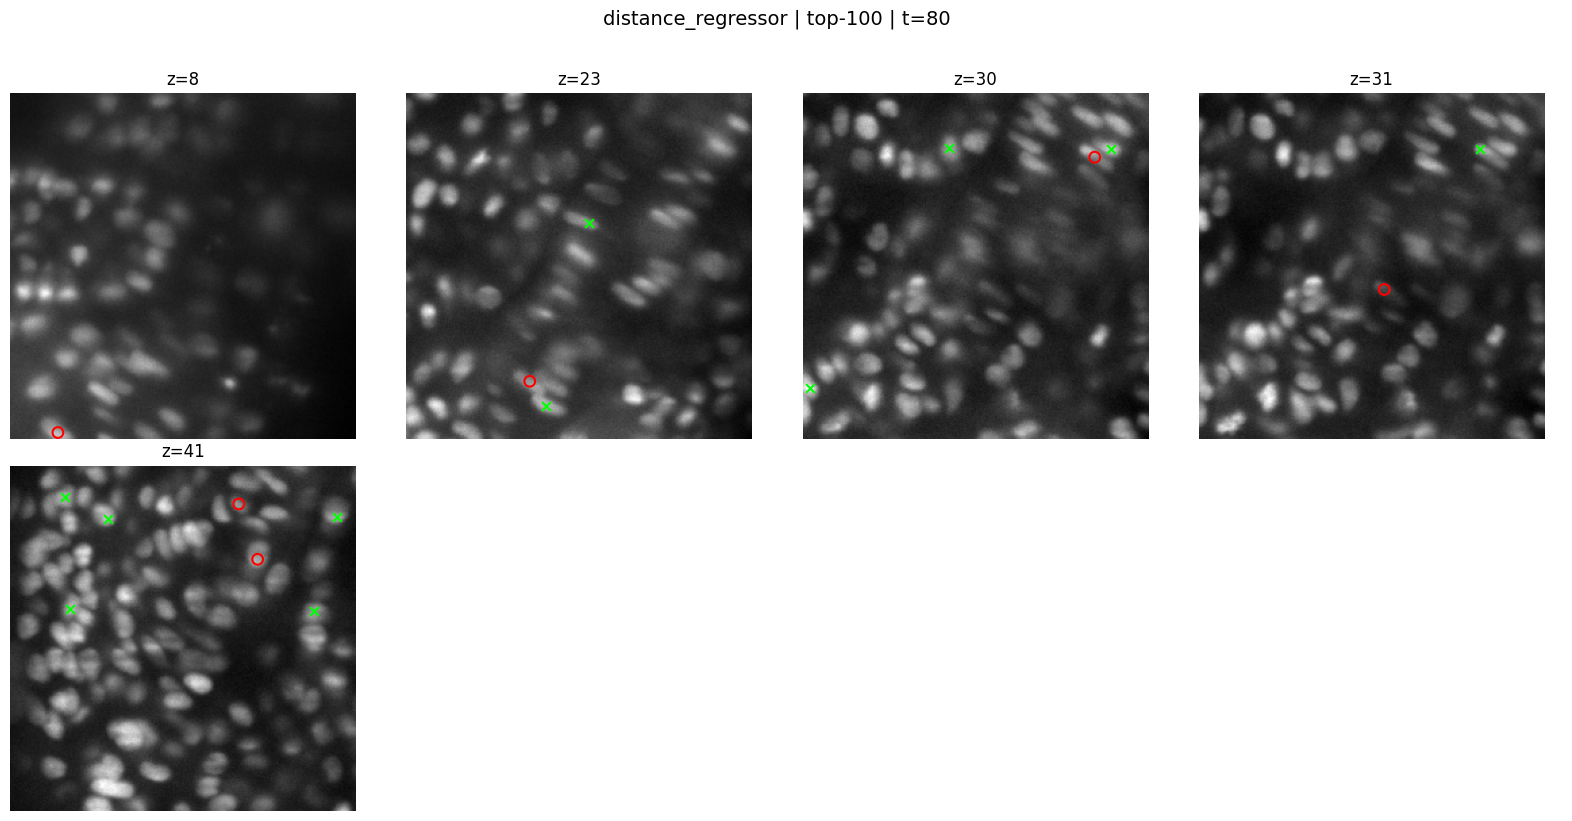

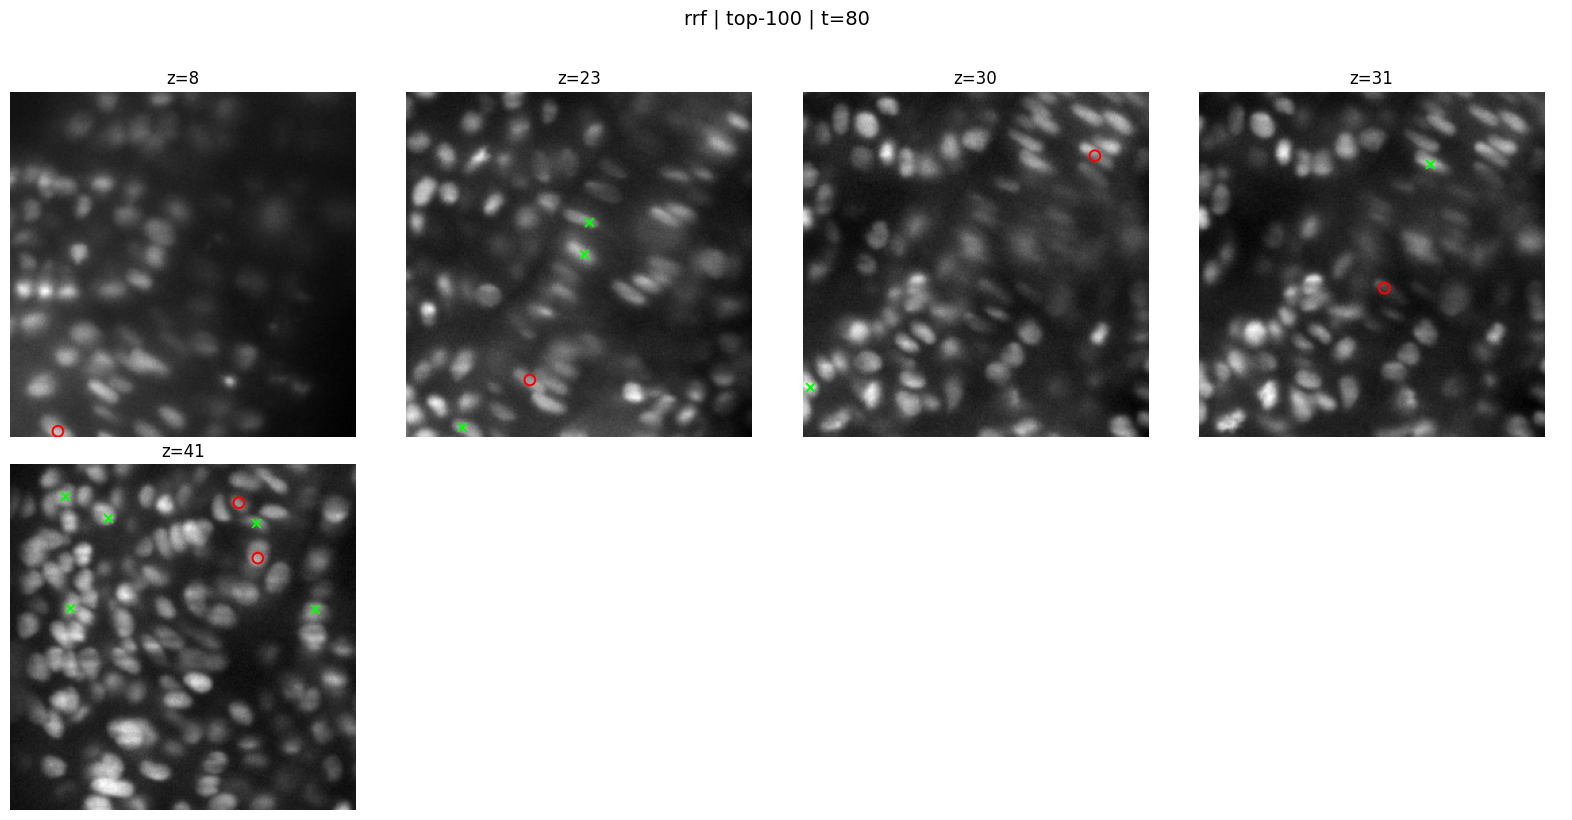

In [33]:

def plot_rank_overlay(frame_3d, gt_t, ranked_df, rank_column, title, top_k=100):
    kept = ranked_df.nsmallest(min(top_k, len(ranked_df)), rank_column)
    z_slices = sorted(gt_t.z.astype(int).unique().tolist())

    if not z_slices:
        print("No GT slices to plot.")
        return

    cols = 4
    rows = int(np.ceil(len(z_slices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, z in zip(axes, z_slices):
        ax.imshow(frame_3d[z], cmap="gray")
        gt_z = gt_t[gt_t.z.astype(int) == z]
        pred_z = kept[kept.z.astype(int) == z]

        if len(pred_z):
            ax.scatter(pred_z.x, pred_z.y, marker="x", s=40, c="lime")
        if len(gt_z):
            ax.scatter(gt_z.x, gt_z.y, facecolors="none", edgecolors="red", s=60, linewidths=1.5)

        ax.set_title(f"z={z}")
        ax.axis("off")

    for ax in axes[len(z_slices):]:
        ax.axis("off")

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


methods_to_plot = {
    "binary_classifier": "binary_rank",
    "distance_regressor": "distance_rank",
    "rrf": "rrf_rank",
}

for t in heldout_timesteps:
    d = ensemble_df[ensemble_df.t == t]
    for method_name, rank_column in methods_to_plot.items():
        plot_rank_overlay(
            heldout_frames[t],
            heldout_gt[t],
            d,
            rank_column,
            title=f"{method_name} | top-100 | t={t}",
            top_k=100,
        )


# Step 37 — Optional Weighted-Rank Sweep

The default weighted ensemble uses:

```text
40% binary rank + 60% distance rank
```

This diagnostic cell tests several weights. Because it uses the held-out frames, treat it as an experiment—not final competition-safe tuning.


In [34]:

weight_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
weight_rows = []

for binary_w in weight_values:
    distance_w = 1.0 - binary_w

    for t in heldout_timesteps:
        d = ensemble_df[ensemble_df.t == t].copy()

        d["temporary_weight_score"] = (
            binary_w * d.binary_normalized_rank
            + distance_w * d.distance_normalized_rank
        )
        d["temporary_weight_rank"] = (
            d.temporary_weight_score
            .rank(method="first", ascending=True)
            .astype(int)
        )

        gt_points = heldout_gt[t][["z", "y", "x"]].to_numpy()

        for top_k in topk_values:
            kept = d.nsmallest(min(top_k, len(d)), "temporary_weight_rank")
            result = evaluate_predictions(
                gt_points,
                kept[["z", "y", "x"]].to_numpy(),
                oracle_radius,
            )

            weight_rows.append({
                "binary_weight": binary_w,
                "distance_weight": distance_w,
                "t": t,
                "top_k": top_k,
                "gt_recall": result["gt_recall"],
                "pred_precision_like": result["pred_precision_like"],
            })

weight_sweep_df = pd.DataFrame(weight_rows)

weight_sweep_summary_df = (
    weight_sweep_df
    .groupby(["binary_weight", "distance_weight", "top_k"], as_index=False)
    .agg(
        mean_gt_recall=("gt_recall", "mean"),
        mean_precision_like=("pred_precision_like", "mean"),
    )
    .sort_values(
        ["top_k", "mean_gt_recall", "mean_precision_like"],
        ascending=[True, False, False],
    )
)

weight_sweep_summary_df


,binary_weight,distance_weight,top_k,mean_gt_recall,mean_precision_like
8,0.4,0.6,25,0.138889,0.0600
12,0.5,0.5,25,0.138889,0.0400
4,0.2,0.8,25,0.083333,0.0200
16,0.6,0.4,25,0.055556,0.0200
20,0.8,0.2,25,0.055556,0.0200
0,0.0,1.0,25,0.000000,0.0000
24,1.0,0.0,25,0.000000,0.0000
5,0.2,0.8,50,0.222222,0.0400
9,0.4,0.6,50,0.222222,0.0400
13,0.5,0.5,50,0.222222,0.0400


# Step 38 — Best Weighted Blend at Each Top-k


In [35]:

best_weight_rows = []

for top_k in topk_values:
    sub = (
        weight_sweep_summary_df[weight_sweep_summary_df.top_k == top_k]
        .sort_values(
            ["mean_gt_recall", "mean_precision_like"],
            ascending=False,
        )
    )
    best = sub.iloc[0]

    best_weight_rows.append({
        "top_k": top_k,
        "best_binary_weight": best.binary_weight,
        "best_distance_weight": best.distance_weight,
        "mean_gt_recall": best.mean_gt_recall,
        "mean_precision_like": best.mean_precision_like,
    })

best_weight_df = pd.DataFrame(best_weight_rows)
best_weight_df


,top_k,best_binary_weight,best_distance_weight,mean_gt_recall,mean_precision_like
0,25,0.4,0.6,0.138889,0.0600
1,50,0.2,0.8,0.222222,0.0400
2,100,0.0,1.0,0.361111,0.0300
3,200,0.0,1.0,0.500000,0.0225


# 📝 Interpretation Notes

## Binary classifier baseline
- Does it remain strongest at `t=60`?
- Does it still struggle at `t=80`?

## Distance regressor baseline
- Does it remain strongest at `t=80`?
- How much candidate compression does it provide at top-100 and top-200?

## Average normalized rank
- Does equal weighting improve consistency?
- Does it outperform either baseline at any cutoff?

## Reciprocal Rank Fusion
- Does RRF rescue candidates ranked highly by only one model?
- Does it improve mean recall across both timepoints?
- Does it reduce catastrophic failure on either timepoint?

## Weighted rank fusion
- Does a 40/60 blend outperform equal weighting?
- Does the preferred weight depend on top-k?

## Final decision
Prefer the method that:

1. performs consistently across both held-out timepoints
2. has the highest mean GT recall
3. retains more oracle-good candidates
4. provides useful candidate compression
5. does not depend on one lucky frame


# 📊 Results

The main Chapter 25 outputs are:

- `ensemble_comparison_df`
- `ensemble_rank_summary_df`
- `average_performance_df`
- `overall_winner_df`
- `oracle_good_ensemble_comparison`
- `weight_sweep_summary_df`
- `best_weight_df`


# 🔍 Analysis

This chapter tests whether the complementary behavior discovered in Chapter 24 translates into a practical improvement.

An ensemble is genuinely useful only if it beats or stabilizes the individual models—not merely because it is more complicated.

The strongest evidence would be:

- higher average GT recall than both baselines
- better oracle-good retention at top-100 or top-200
- fewer failures across held-out timepoints
- useful candidate compression before tracking


# 📝 What I Learned

Today I learned that:

- classifier probabilities and predicted distances should not be directly averaged
- normalized ranks provide a shared fusion scale
- average normalized rank is a simple ensemble baseline
- RRF rewards candidates that either model ranks highly
- weighted rank fusion can reflect unequal model strengths
- every ensemble must be compared against its component baselines
- the best method should generalize across multiple held-out timepoints


# Chapter 25 Conclusion Template

## Binary classifier
- best result:
- strongest timepoint:
- weakest timepoint:

## Distance regressor
- best result:
- strongest timepoint:
- weakest timepoint:

## Average normalized rank
- best result:
- did it beat both baselines?

## Reciprocal Rank Fusion
- best result:
- did it improve consistency?

## Weighted rank fusion
- best weight:
- best result:

## Final selection

The ranking method selected for the next stage is:

```text
____________________________
```

Reason:

```text
____________________________________________________
____________________________________________________
```

## Suggested Chapter 26

### Build a Final Ensemble Candidate Detector Pipeline

Possible goals:

- package LoG detection, NMS, feature extraction, model scoring, and ensemble ranking into one function
- select a practical top-k cutoff
- run the detector across additional timepoints
- prepare ranked detections for temporal linking and full cell tracking
